# UI Object Classification Evaluation
We will compare 3 models
1. Proposed model, modified from Sketch-DeepNet, we name it Sketch2CodeX
1. Sketch-DeepNet
1. YOLOv11

You can download the above models in: https://huggingface.co/agzulvani/sketch-ui-deep-net/tree/main

In [17]:
# Define the libraries and modules to be used in the notebook
import keras
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import os
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [18]:
def calculate_metrics(true_labels, predicted_labels, test_class_names):
    # Convert true labels and predicted labels to one-hot encoding
    true_labels_one_hot = np.zeros((len(true_labels), len(test_class_names)))
    predicted_labels_one_hot = np.zeros((len(predicted_labels), len(test_class_names)))

    for i, label in enumerate(true_labels):
        true_labels_one_hot[i, test_class_names.index(label)] = 1

    for i, label in enumerate(predicted_labels):
        predicted_labels_one_hot[i, test_class_names.index(label)] = 1

    # Calculate average precision for each class -----------------
    average_precisions = []
    ap_labels = []
    for i in range(len(test_class_names)):
        average_precisions.append(average_precision_score(true_labels_one_hot[:, i], predicted_labels_one_hot[:, i]))
        ap_labels.append(f"{test_class_names[i]}, Average Precision: {average_precisions[i]:.2f}")

    ap_labels.sort()
    for i in range(len(ap_labels)):
        print(ap_labels[i])

    # Calculate mean Average Precision (mAP) ----------------------
    mAP = np.mean(average_precisions)
    print(f"Mean Average Precision (mAP): {mAP:.2f}")

    # Calculate precision for each class
    precision = precision_score(true_labels, predicted_labels, labels=test_class_names, average=None)
    precision_labels = []
    for class_name, prec in zip(test_class_names, precision):
        precision_labels.append(f"{class_name}: {prec:.2f}")
        # print(f"{class_name}: {prec:.2f}")

    print("Precision-------------------")
    precision_labels.sort()
    for i in range(len(precision_labels)):
        print(precision_labels[i])

    # Calculate recall for each class
    recall = recall_score(true_labels, predicted_labels, labels=test_class_names, average=None)
    recall_labels = []
    for class_name, rec in zip(test_class_names, recall):
        recall_labels.append(f"{class_name}: {rec:.2f}")

    recall_labels.sort()
    print("Recall-------------------")
    for i in range(len(recall_labels)):
        print(recall_labels[i])

    # Calculate F1 score for each class
    f1 = f1_score(true_labels, predicted_labels, labels=test_class_names, average=None)
    f1_labels = []
    for class_name, f1_score_value in zip(test_class_names, f1):
        f1_labels.append(f"{class_name}: {f1_score_value:.2f}")
        # print(f"F1 Score for class {class_name}: {f1_score_value:.2f}")

    f1_labels.sort()
    print("F1 Score-------------------")
    for i in range(len(f1_labels)):
        print(f1_labels[i])

    # Build a combined metrics table
    accuracy = accuracy_score(true_labels, predicted_labels)

    rows = []
    for class_name, prec, rec, f1_value, ap in zip(
        test_class_names, precision, recall, f1, average_precisions
    ):
        rows.append(
            f"| {class_name} | {prec:.2f} | {rec:.2f} | {f1_value:.2f} | {ap:.2f}   |"
        )

    rows.sort()

    markdown_table = "\n".join([
        "| Class |  Precision | Recall | F1 | AP |",
        "|---|---:|---:|---:|---:|",
        *rows,
        "",
        f"**Accuracy:** {accuracy:.2f}  ",
        f"**mAP:** {mAP:.2f}"
    ])

    safe_class_names = [c.replace('_', r'\_') for c in test_class_names]

    latex_rows = "\n".join(
        f"{class_name} & {ap:.2f} & {prec:.2f} & {rec:.2f} & {f1_value:.2f} \\\\"
        for class_name, ap, prec, rec, f1_value in zip(
            safe_class_names, average_precisions, precision, recall, f1
        )
    )

    latex_table = rf"""
    \begin{{table}}[ht]
    \centering
    \begin{{tabular}}{{lrrrr}}
    \hline
    Class & Average Precision & Precision & Recall & F1 Score \\
    \hline
    {latex_rows}
    \hline
    \end{{tabular}}
    \caption{{Classification performance by class. Accuracy = {accuracy:.2f}, mAP = {mAP:.2f}.}}
    \end{{table}}
    """

    print("Markdown table:\n")
    print(markdown_table)

    print("\nLaTeX table:\n")
    print(latex_table)


In [19]:
def generate_confusion_matrix(true_labels, predicted_labels, test_class_names, show_nominal = False):
    # Generate the confusion matrix
    sorted_class_names = sorted(test_class_names)
    cm = confusion_matrix(true_labels, predicted_labels, labels=sorted_class_names)
    short_class_names = ['\n'.join(class_name.split('-')) for class_name in sorted_class_names]
    label_class = short_class_names

    # Calculate the percentage for each cell in the confusion matrix
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=label_class)

    # Set the width and height of the plot
    fig, ax = plt.subplots(figsize=(20, 18))
    disp.plot(cmap=plt.cm.Blues, ax=ax, values_format=".2f", xticks_rotation='vertical')

    # Adjust font size
    for labels in [ax.get_xticklabels(), ax.get_yticklabels()]:
        for label in labels:
            label.set_fontsize(9)  # Adjust the font size as needed

    if show_nominal:
        # Display the confusion matrix
        fig, ax2 = plt.subplots(figsize=(20, 18))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_class)
        disp.plot(cmap=plt.cm.Blues, ax=ax2)

        for labels in [ax2.get_xticklabels(), ax2.get_yticklabels()]:
            for label in labels:
                label.set_fontsize(9)  # Adjust the font size as needed
    plt.show()

In [20]:
def run_evaluation(model, test_dataset_path, test_class_names, image_width, image_height): 
    # Run evaluation on the test dataset
    true_labels = []
    predicted_labels = []

    # Loop through each class foldex
    for class_name in test_class_names:
        class_folder = os.path.join(test_dataset_path, class_name)
        for image_file in os.listdir(class_folder):
            if image_file.endswith(('.png', '.jpg', '.jpeg')):
                image_path = os.path.join(class_folder, image_file)
                image = Image.open(image_path).convert("L")
                image = image.resize((image_width, image_height))
                image_array = np.array(image) / 255.0
                image_array = np.expand_dims(image_array, axis=0)

                predictions = model.predict(image_array, verbose=0)
                predicted_class_index = np.argmax(predictions[0])
                predicted_class_name = test_class_names[predicted_class_index]

                true_labels.append(class_name)
                predicted_labels.append(predicted_class_name)

    generate_confusion_matrix(true_labels, predicted_labels, test_class_names)
    calculate_metrics(true_labels, predicted_labels, test_class_names)

In [21]:
# Setup the parameters for image dimensions
image_width = 200
image_height = 141

test_dataset_path = "/Users/aguszulvani/privacy/MKOM/1-PROPOSAL-TESIS/CODE/datatest/test"

# Get the list of class names from the subfolders
test_class_names = [name for name in os.listdir(test_dataset_path) if os.path.isdir(os.path.join(test_dataset_path, name))]

# Sketch2CodeX model path and load the model
sketch2codex_model_path = "/Users/aguszulvani/LEARNING-ML/DSL/FINAL_RESULT/CLASSIFICATION-EVALUATION/MODELS/Sketch2CodeX-2026-03-31.keras"
sketch2codex_model = load_model(sketch2codex_model_path)

# Sketch-DeepNet model path and load the model
sketch_deepnet_model_path = "/Users/aguszulvani/LEARNING-ML/DSL/FINAL_RESULT/CLASSIFICATION-EVALUATION/MODELS/Sketch-DeepNet-e23-mPrecission-2026-01-29.keras"
sketch_deepnet_model = load_model(sketch_deepnet_model_path)

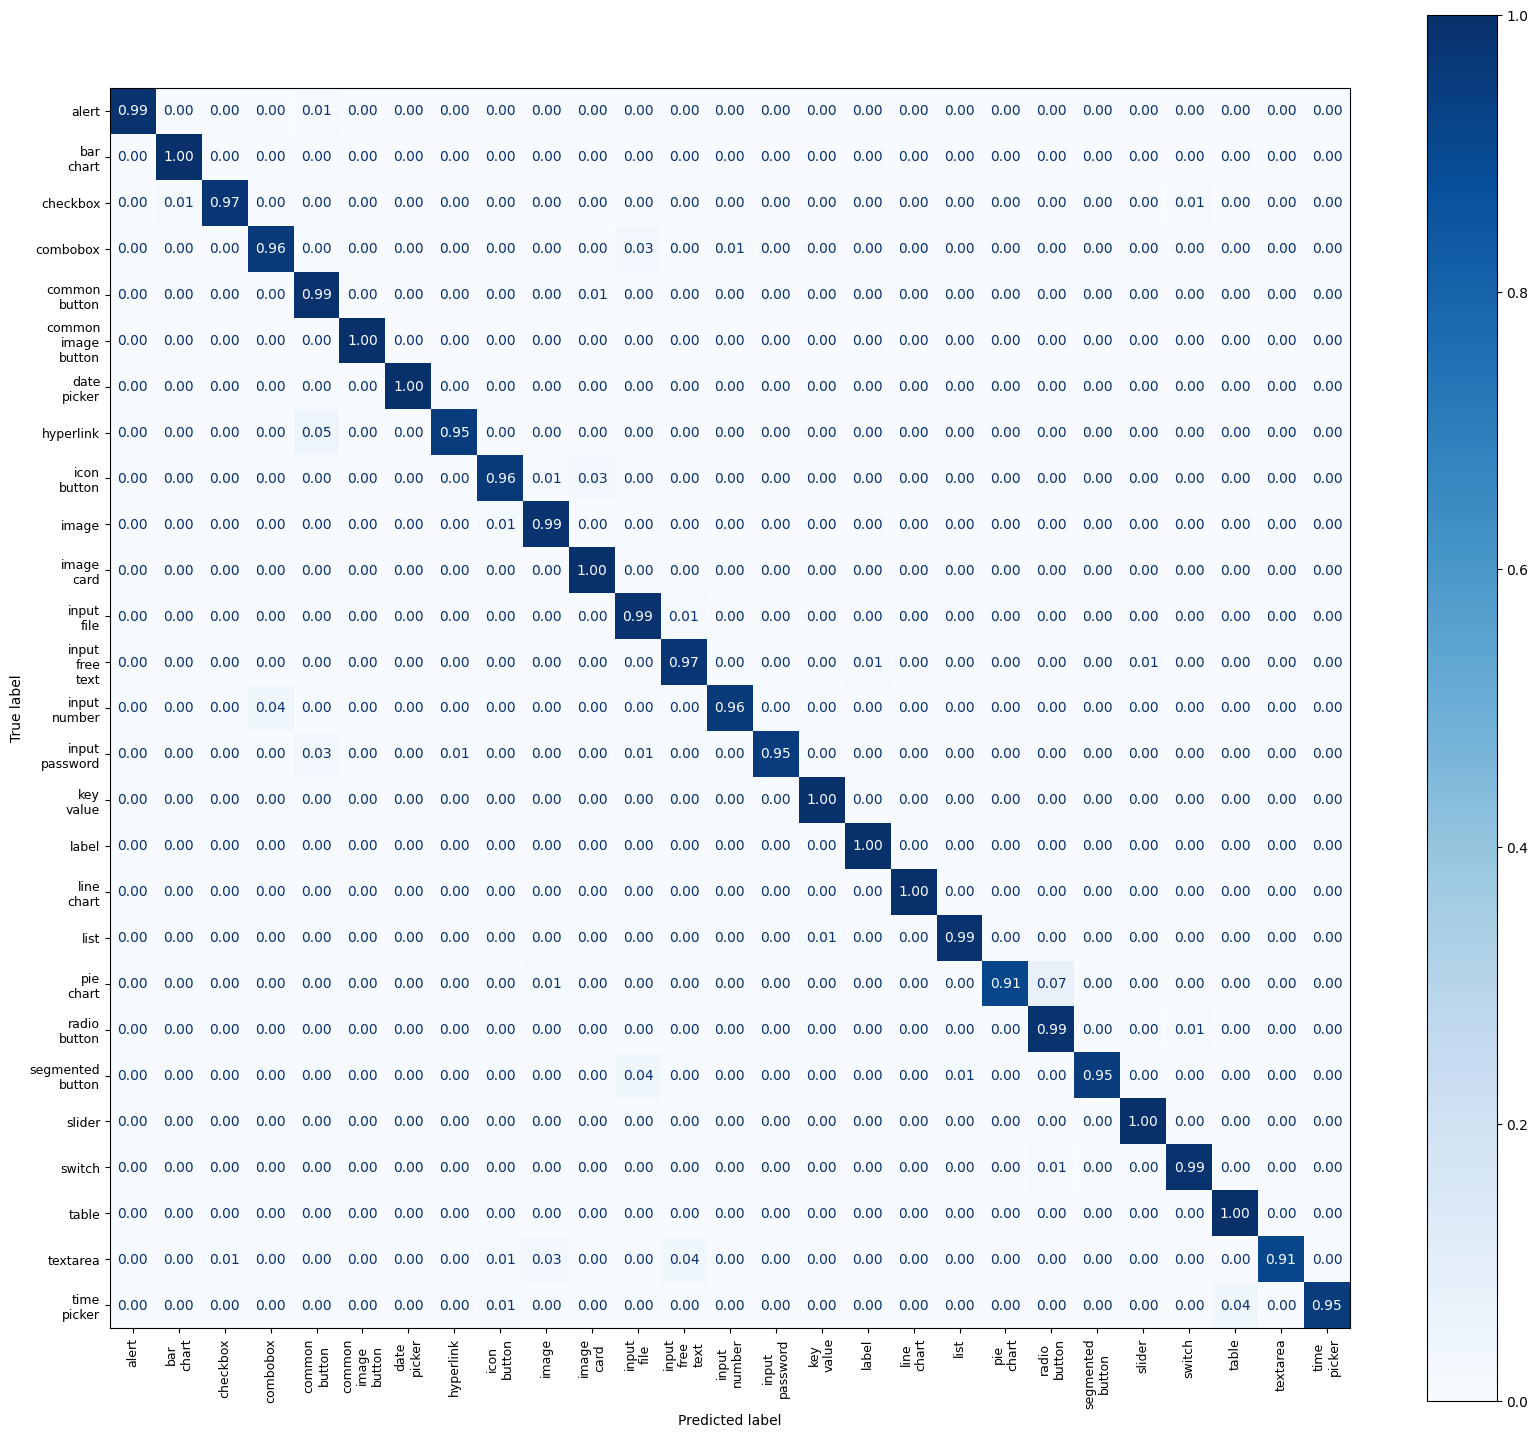

alert, Average Precision: 0.99
bar-chart, Average Precision: 0.99
checkbox, Average Precision: 0.96
combobox, Average Precision: 0.93
common-button, Average Precision: 0.91
common-image-button, Average Precision: 1.00
date-picker, Average Precision: 1.00
hyperlink, Average Precision: 0.94
icon-button, Average Precision: 0.93
image, Average Precision: 0.94
image-card, Average Precision: 0.96
input-file, Average Precision: 0.92
input-free-text, Average Precision: 0.93
input-number, Average Precision: 0.95
input-password, Average Precision: 0.95
key-value, Average Precision: 0.99
label, Average Precision: 0.99
line-chart, Average Precision: 1.00
list, Average Precision: 0.98
pie-chart, Average Precision: 0.92
radio-button, Average Precision: 0.91
segmented-button, Average Precision: 0.95
slider, Average Precision: 0.99
switch, Average Precision: 0.96
table, Average Precision: 0.96
textarea, Average Precision: 0.92
time-picker, Average Precision: 0.95
Mean Average Precision (mAP): 0.96
Pre

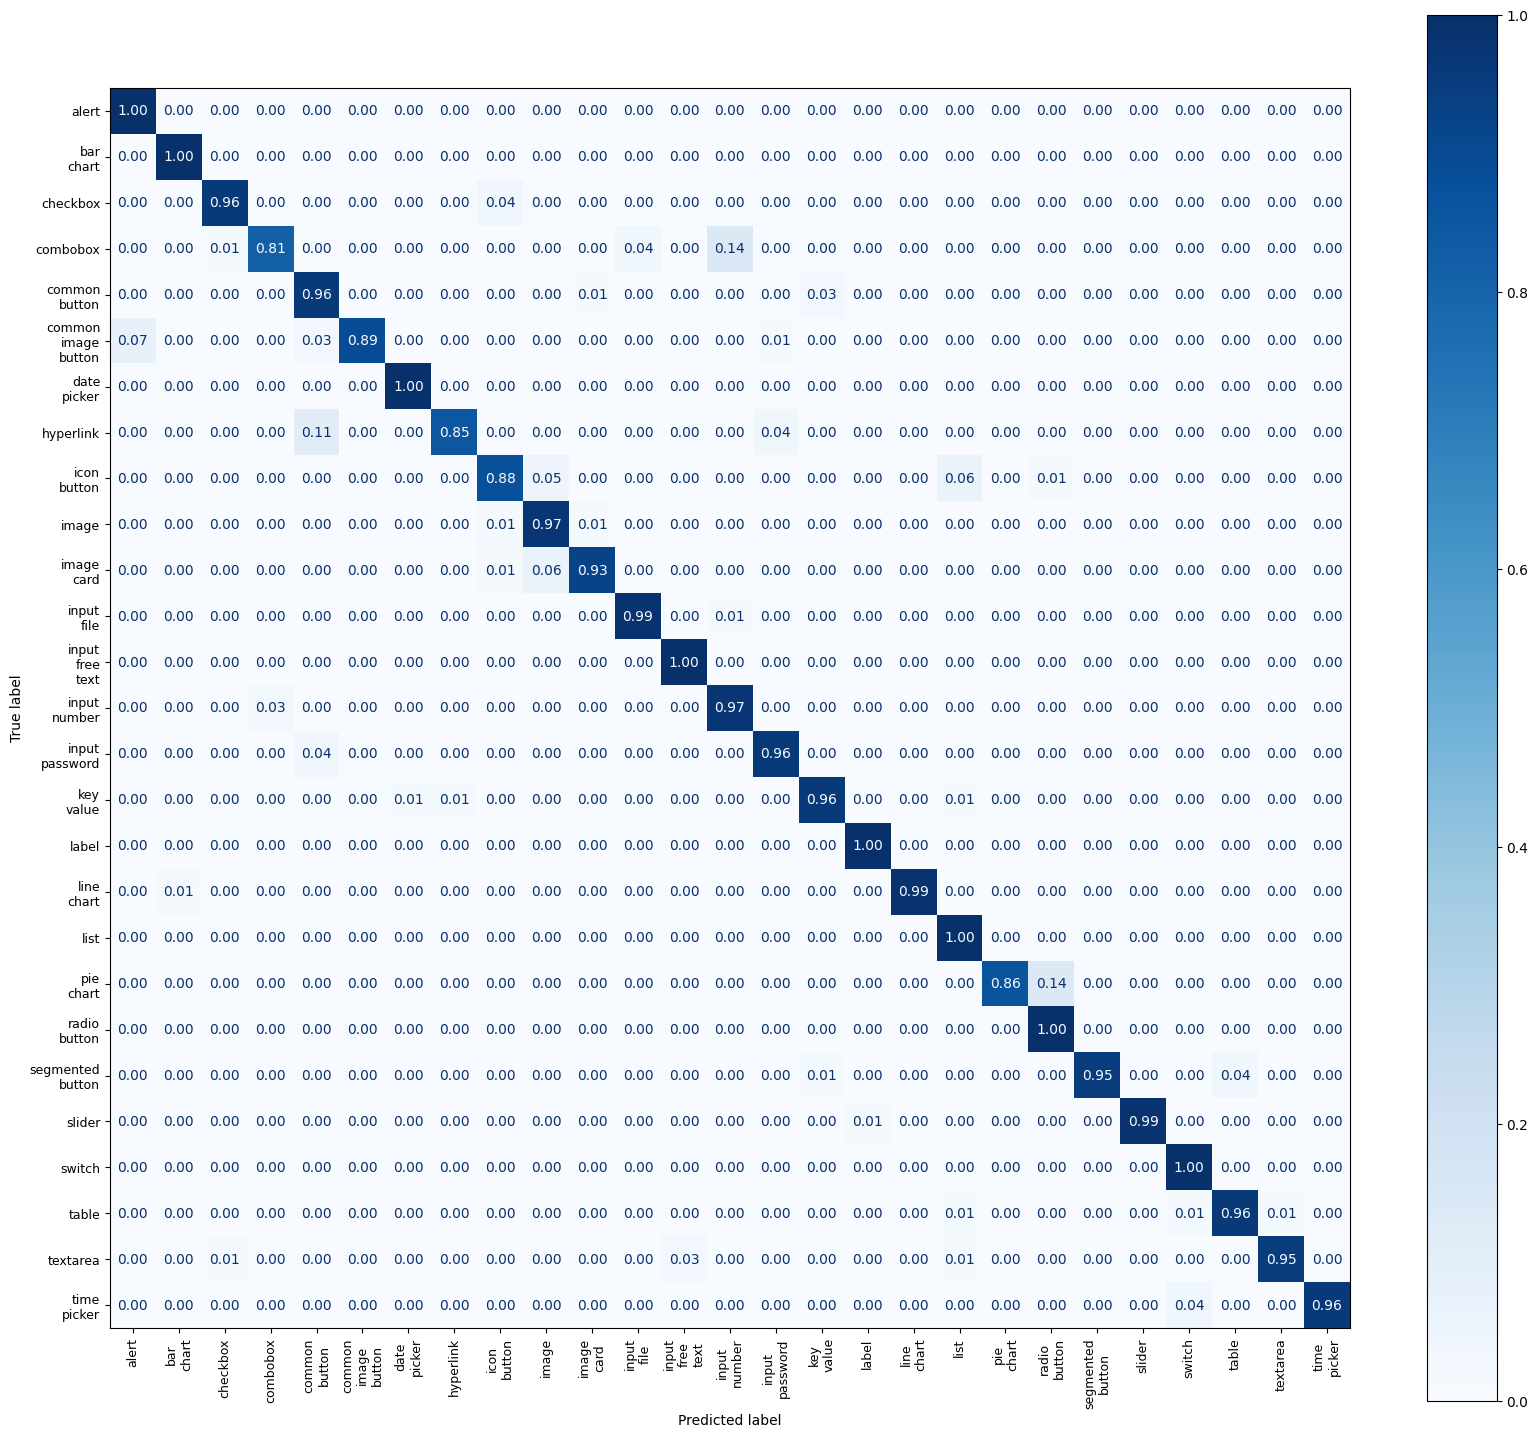

alert, Average Precision: 0.93
bar-chart, Average Precision: 0.99
checkbox, Average Precision: 0.94
combobox, Average Precision: 0.80
common-button, Average Precision: 0.82
common-image-button, Average Precision: 0.89
date-picker, Average Precision: 0.99
hyperlink, Average Precision: 0.84
icon-button, Average Precision: 0.82
image, Average Precision: 0.88
image-card, Average Precision: 0.90
input-file, Average Precision: 0.95
input-free-text, Average Precision: 0.98
input-number, Average Precision: 0.85
input-password, Average Precision: 0.92
key-value, Average Precision: 0.93
label, Average Precision: 0.99
line-chart, Average Precision: 0.99
list, Average Precision: 0.91
pie-chart, Average Precision: 0.87
radio-button, Average Precision: 0.87
segmented-button, Average Precision: 0.95
slider, Average Precision: 0.99
switch, Average Precision: 0.95
table, Average Precision: 0.93
textarea, Average Precision: 0.94
time-picker, Average Precision: 0.96
Mean Average Precision (mAP): 0.92
Pre

In [22]:
run_evaluation(sketch2codex_model, test_dataset_path, test_class_names, image_width, image_height)
run_evaluation(sketch_deepnet_model, test_dataset_path, test_class_names, image_width, image_height)

In [23]:
from ultralytics import YOLO
yolo_model = YOLO('/Users/aguszulvani/privacy/MKOM/1-PROPOSAL-TESIS/EXPERIENCE-RESULT/YOLO/YOLOv11/weights/best.pt')
yolo_v8_class_names = ['alert','bar-chart','checkbox', 'combobox', 'common-button',
                       'common-image-button','date-picker','hyperlink','icon-button', 
                       'image','image-card','input-file', 'input-free-text','input-number',
                       'input-password','key-value','label','line-chart', 'list','pie-chart', 
                       'radio-button','segmented-button','slider','switch', 
                       'table','textarea','time-picker'] 

image_width = 224
image_height = 160 

# Initialize lists to store true labels and predicted labels
true_labels = []
predicted_labels = []

# Loop through each class foldex
for class_name in yolo_v8_class_names:
    class_folder = os.path.join(test_dataset_path, class_name)
    for image_file in os.listdir(class_folder):
        if image_file.endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(class_folder, image_file)
            results = yolo_model.predict(image_path, imgsz=(image_width, image_height), verbose=False)
            # Process results list
            for result in results:
                boxes = result.boxes  

                if len(boxes.cls) > 0:
                    predicted_class_index = int(boxes.cls[0])
                    predicted_class_name = yolo_v8_class_names[predicted_class_index]

            true_labels.append(class_name)
            predicted_labels.append(predicted_class_name)

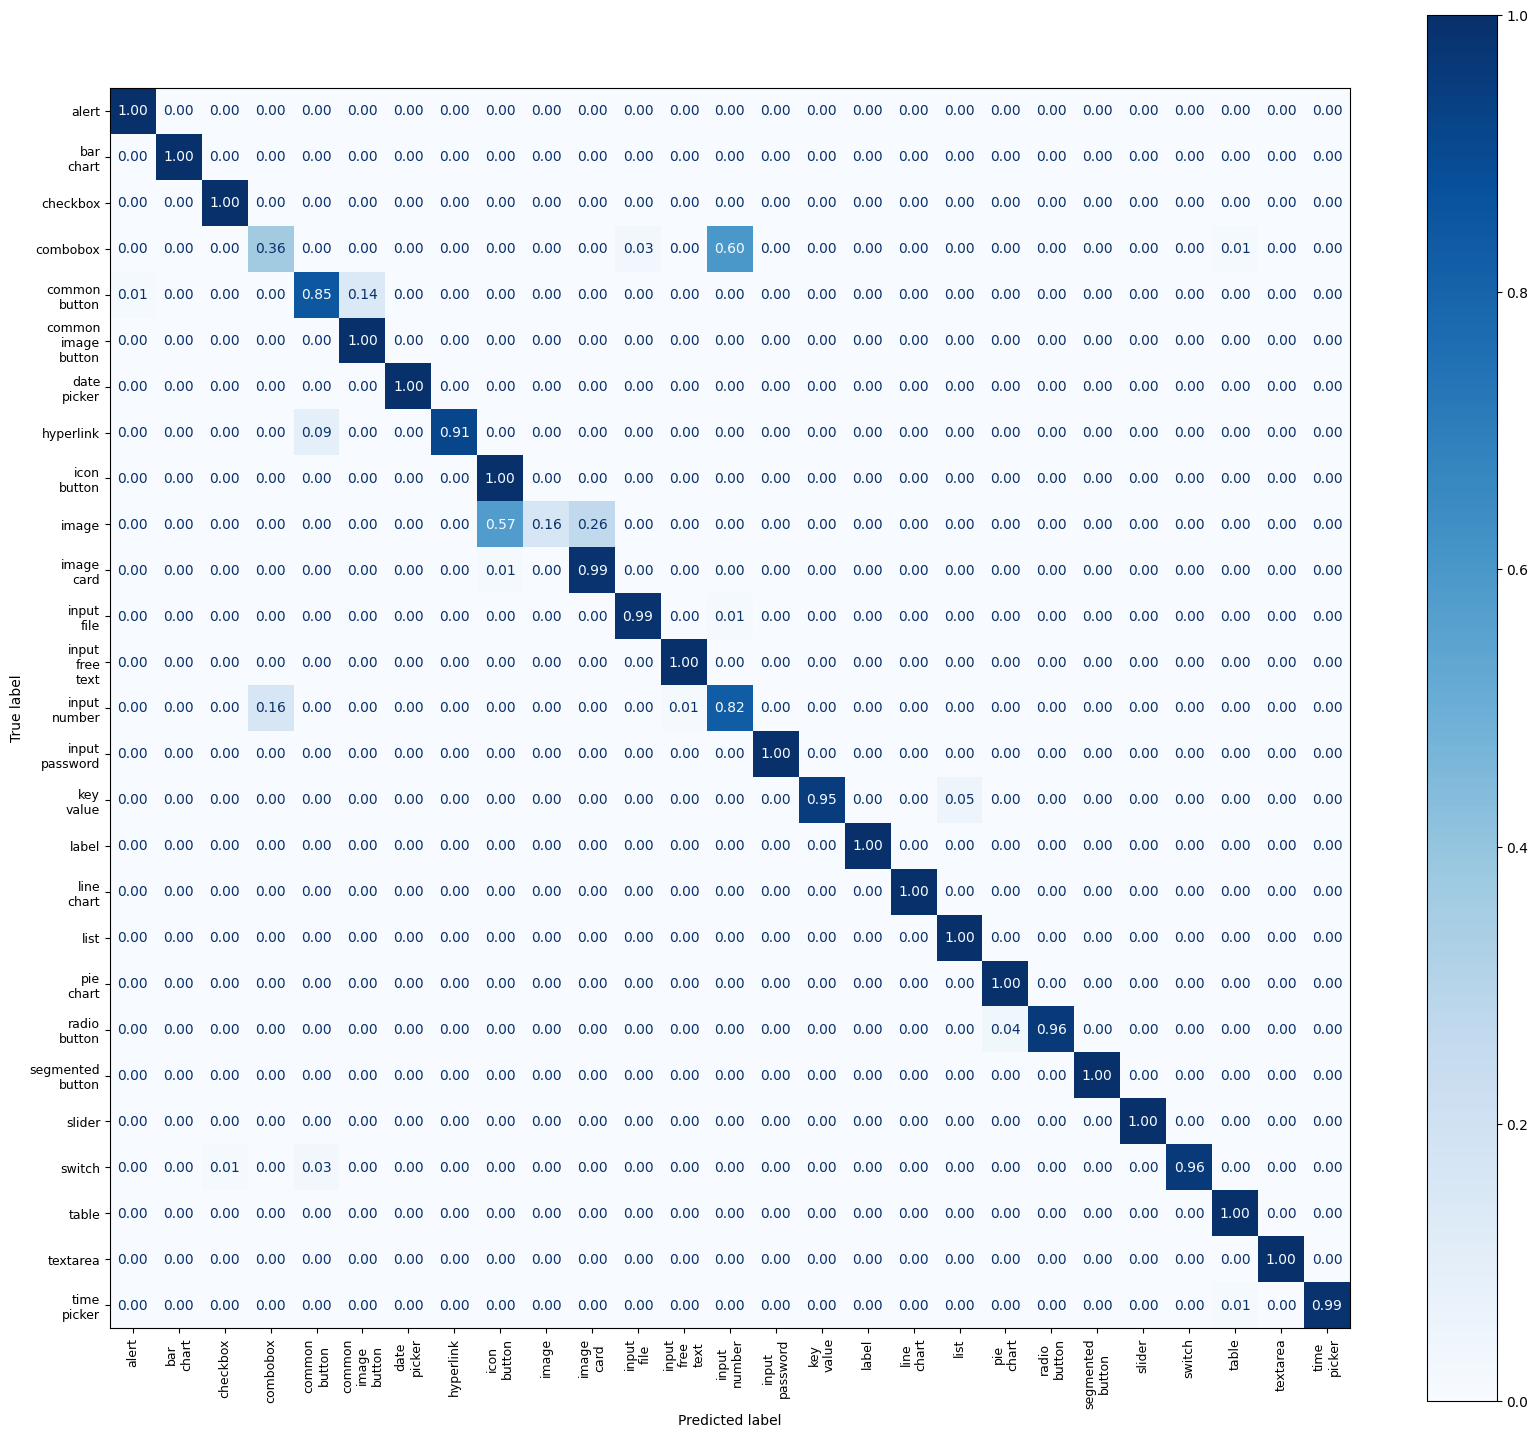

alert, Average Precision: 0.99
bar-chart, Average Precision: 1.00
checkbox, Average Precision: 0.99
combobox, Average Precision: 0.27
common-button, Average Precision: 0.76
common-image-button, Average Precision: 0.88
date-picker, Average Precision: 1.00
hyperlink, Average Precision: 0.92
icon-button, Average Precision: 0.63
image, Average Precision: 0.19
image-card, Average Precision: 0.78
input-file, Average Precision: 0.96
input-free-text, Average Precision: 0.99
input-number, Average Precision: 0.48
input-password, Average Precision: 1.00
key-value, Average Precision: 0.95
label, Average Precision: 1.00
line-chart, Average Precision: 1.00
list, Average Precision: 0.95
pie-chart, Average Precision: 0.96
radio-button, Average Precision: 0.96
segmented-button, Average Precision: 1.00
slider, Average Precision: 1.00
switch, Average Precision: 0.96
table, Average Precision: 0.98
textarea, Average Precision: 1.00
time-picker, Average Precision: 0.99
Mean Average Precision (mAP): 0.87
Pre

In [24]:
generate_confusion_matrix(true_labels, predicted_labels, yolo_v8_class_names)
calculate_metrics(true_labels, predicted_labels, yolo_v8_class_names)